In [1]:
#Download and unzip files
!pip3 install scikit-learn
!pip install "wheel==0.34.2"
!wget http://cs.gmu.edu/~kosecka/cs747/cities_test.txt
!wget http://cs.gmu.edu/~kosecka/cs747/cities_val.zip
!wget http://cs.gmu.edu/~kosecka/cs747/cities_train.zip
!sudo apt-get install unzip
!unzip cities_val.zip
!unzip cities_train.zip
from os.path import exists
from wheel.pep425tags import get_abbr_impl, get_impl_ver, get_abi_tag
platform = '{}{}-{}'.format(get_abbr_impl(), get_impl_ver(), get_abi_tag())
cuda_output = !ldconfig -p|grep cudart.so|sed -e 's/.*\.\([0-9]*\)\.\([0-9]*\)$/cu\1\2/'
accelerator = cuda_output[0] if exists('/dev/nvidia0') else 'cpu'
!pip3 install https://download.pytorch.org/whl/cu100/torch-1.0.1-cp36-cp36m-linux_x86_64.whl
!pip3 install torch torchvision

import torch
device =  torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
'unzip' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.
C:\Users\anish\PycharmProjects\DeepLearningAss3\.venv\Lib\site-packages\wheel\pep425tags.py:80: RuntimeWarning: Config variable 'Py_DEBUG' is unset, Python ABI tag may be incorrect
  if get_flag('Py_DEBUG',

[notice] A new release of pip is available: 25.1.1 -> 26.0.1

In [2]:
#Verfiy file download
!head train/af.txt
!printf "\n"
!head val/af.txt
!printf "\n"
!head cities_test.txt
!printf "\n"
#Verify CUDA acceleration should print cuda:0
print(device)

'head' is not recognized as an internal or external command,
operable program or batch file.
'printf' is not recognized as an internal or external command,
operable program or batch file.
'head' is not recognized as an internal or external command,
operable program or batch file.
'printf' is not recognized as an internal or external command,
operable program or batch file.
'head' is not recognized as an internal or external command,
operable program or batch file.


cpu


'printf' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# Mount your google drive.
# Use this to save your PyTorch model for submission
from google.colab import drive
drive.mount('/content/gdrive')
#!mkdir /content/gdrive/My\ Drive/Colab Notebooks/A3-RNN
#Test drive access.
#You should have a test.txt under a new folder cis530_hw6 in your Google drive
with open('/content/gdrive/My Drive/Colab Notebooks/A3-RNN/test.txt', 'w') as f:
  f.write('This is a test!')

ModuleNotFoundError: No module named 'google.colab'

Working directory: C:\Users\anish\PycharmProjects\DeepLearningAss3
Using device: cpu
Training samples: 27000
Validation samples: 900
Training on dataset with n = 27000
Epoch 01/15 | Train Loss: 1.8703 | Val Loss: 1.7549 | Val Acc: 0.3733
Epoch 02/15 | Train Loss: 1.6719 | Val Loss: 1.5932 | Val Acc: 0.4289
Epoch 03/15 | Train Loss: 1.5880 | Val Loss: 1.6374 | Val Acc: 0.4211
Epoch 04/15 | Train Loss: 1.5153 | Val Loss: 1.5986 | Val Acc: 0.4333
Epoch 05/15 | Train Loss: 1.4427 | Val Loss: 1.4232 | Val Acc: 0.5178
Epoch 06/15 | Train Loss: 1.3604 | Val Loss: 1.4465 | Val Acc: 0.5056
Epoch 07/15 | Train Loss: 1.2745 | Val Loss: 1.3286 | Val Acc: 0.5544
Epoch 08/15 | Train Loss: 1.2093 | Val Loss: 1.2967 | Val Acc: 0.5578
Epoch 09/15 | Train Loss: 1.1494 | Val Loss: 1.2061 | Val Acc: 0.5856
Epoch 10/15 | Train Loss: 1.1104 | Val Loss: 1.2796 | Val Acc: 0.5733
Epoch 11/15 | Train Loss: 1.0742 | Val Loss: 1.2108 | Val Acc: 0.5922
Epoch 12/15 | Train Loss: 1.0449 | Val Loss: 1.1545 | Val Acc:

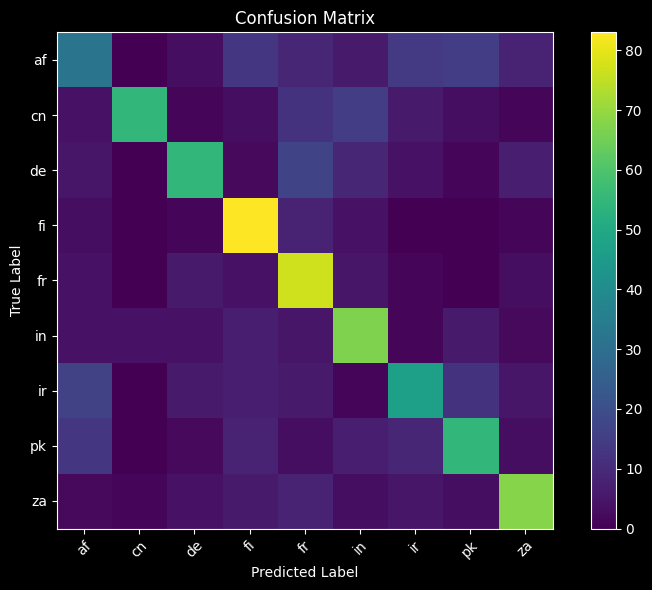


Confusion Matrix:
[[32  0  3 13  9  6 14 15  8]
 [ 4 55  1  3 12 15  6  3  1]
 [ 5  0 55  2 17  9  4  1  7]
 [ 3  0  1 83  8  4  0  0  1]
 [ 4  0  6  4 77  5  1  0  3]
 [ 4  4  4  7  5 67  1  6  2]
 [16  0  6  7  6  1 47 12  5]
 [13  0  2  8  3  7  9 55  3]
 [ 2  1  4  6  8  3  5  3 68]]


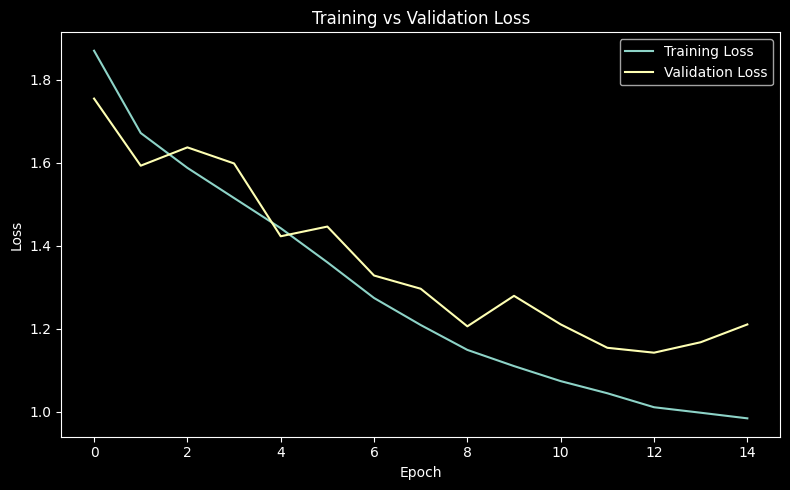

Saved trained model to model_classify.pth
Saved test predictions to labels.txt


In [1]:
import os
import codecs
import random
import string
import time
import math

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# -------------------------------------------------
# Constants
# -------------------------------------------------
languages = ["af", "cn", "de", "fi", "fr", "in", "ir", "pk", "za"]

# Tutorial style keeps a fixed allowed character set.
# Current tutorial also mentions allowing an OOV marker like "_",
# but for this assignment we can safely keep the simpler set.
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)
n_categories = len(languages)

device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
torch.set_default_device(device)

# -------------------------------------------------
# Character helpers
# -------------------------------------------------
def unicodeToAscii(s):
    return "".join(c for c in s if c in all_letters)

def letterToIndex(letter):
    return all_letters.find(letter)

def line_to_tensor(line):
    """
    Convert a word to a tensor of shape:
    [line_length, 1, n_letters]
    exactly in the tutorial style.
    """
    tensor = torch.zeros(len(line), 1, n_letters, device=device)
    for li, letter in enumerate(line):
        idx = letterToIndex(letter)
        if idx != -1:
            tensor[li][0][idx] = 1
    return tensor

def label_to_tensor(label_index):
    return torch.tensor([label_index], dtype=torch.long, device=device)

# -------------------------------------------------
# Data loading
# -------------------------------------------------
def getWords(baseDir, lang, train=True):
    """
    Adjust validation path if your folder is:
      cities_val/af.txt
    instead of:
      cities_val/val/af.txt
    """
    if train:
        filename = os.path.join(baseDir, "cities_train", "train", f"{lang}.txt")
    else:
        filename = os.path.join(baseDir, "cities_val", "val", f"{lang}.txt")

    words = []
    with codecs.open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = unicodeToAscii(line.strip())
            if line:
                words.append(line)
    return words

def get_test_words(baseDir):
    filename = os.path.join(baseDir, "cities_test.txt")
    words = []
    with codecs.open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = unicodeToAscii(line.strip())
            if line:
                words.append(line)
    return words

def build_dataset(baseDir, train=True):
    """
    Build tutorial-style dataset:
    list of tuples:
      (label_tensor, text_tensor, label_index, text_string)
    """
    dataset = []
    for lang_idx, lang in enumerate(languages):
        words = getWords(baseDir, lang, train=train)
        for word in words:
            dataset.append(
                (
                    label_to_tensor(lang_idx),
                    line_to_tensor(word),
                    lang_idx,
                    word
                )
            )
    return dataset

# -------------------------------------------------
# Model
# -------------------------------------------------
class CharRNN(nn.Module):
    """
    This is closer to the current tutorial:
      rnn -> hidden -> linear -> log_softmax
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        # line_tensor shape: [seq_len, 1, n_letters]
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)
        return output

# -------------------------------------------------
# Output helpers
# -------------------------------------------------
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

# -------------------------------------------------
# Training / evaluation helpers
# -------------------------------------------------
def split_into_batches(n_items, batch_size):
    indices = list(range(n_items))
    random.shuffle(indices)
    return np.array_split(indices, max(1, len(indices) // batch_size))

def dataset_loss(model, dataset, criterion):
    """
    Compute average loss over a dataset.
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for label_tensor, text_tensor, _, _ in dataset:
            output = model(text_tensor)
            loss = criterion(output, label_tensor)
            total_loss += loss.item()

    return total_loss / max(len(dataset), 1)

def predict_dataset(model, dataset):
    """
    Returns y_true, y_pred, raw texts
    """
    model.eval()
    y_true, y_pred, texts = [], [], []

    with torch.no_grad():
        for label_tensor, text_tensor, label, text in dataset:
            output = model(text_tensor)
            _, pred_idx = label_from_output(output, languages)
            y_true.append(label)
            y_pred.append(pred_idx)
            texts.append(text)

    return y_true, y_pred, texts

def evaluate_accuracy(model, dataset):
    y_true, y_pred, _ = predict_dataset(model, dataset)
    return accuracy_score(y_true, y_pred)

def train_model(
    model,
    train_set,
    val_set,
    n_epoch=15,
    batch_size=64,
    learning_rate=0.15,
    report_every=1,
    clip=3.0
):
    """
    This follows the current tutorial structure closely:
    - SGD optimizer
    - minibatches built manually
    - batch loss accumulation
    - gradient clipping
    - report losses per epoch
    """
    criterion = nn.NLLLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    val_accuracies = []

    model.train()
    start = time.time()
    print(f"Training on dataset with n = {len(train_set)}")

    for epoch in range(1, n_epoch + 1):
        model.train()
        current_loss = 0.0

        batches = split_into_batches(len(train_set), batch_size)

        for batch in batches:
            batch_loss = 0.0

            for i in batch:
                label_tensor, text_tensor, _, _ = train_set[i]
                output = model(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            batch_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / max(len(batch), 1)

        avg_train_loss = current_loss / max(len(batches), 1)
        avg_val_loss = dataset_loss(model, val_set, criterion)
        val_acc = evaluate_accuracy(model, val_set)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        if epoch % report_every == 0:
            print(
                f"Epoch {epoch:02d}/{n_epoch} | "
                f"Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {avg_val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

    elapsed = time.time() - start
    print(f"Training finished in {elapsed:.2f} seconds")

    return train_losses, val_losses, val_accuracies

# -------------------------------------------------
# Plotting
# -------------------------------------------------
def plot_losses(train_losses, val_losses, save_path="loss_plot.png"):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, save_path="confusion_matrix.png"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

    return cm

# -------------------------------------------------
# Test prediction writer
# -------------------------------------------------
def predict_test_file(model, baseDir, output_file="labels.txt"):
    test_words = get_test_words(baseDir)
    preds = []

    model.eval()
    with torch.no_grad():
        for word in test_words:
            text_tensor = line_to_tensor(word)
            output = model(text_tensor)
            pred_label, pred_idx = label_from_output(output, languages)
            preds.append(pred_label)

    with open(output_file, "w", encoding="utf-8") as f:
        for label in preds:
            f.write(label + "\n")

    print(f"Saved test predictions to {output_file}")
    return preds

# -------------------------------------------------
# Main
# -------------------------------------------------
def run():
    baseDir = "."

    print("Working directory:", os.getcwd())
    print("Using device:", device)

    train_set = build_dataset(baseDir, train=True)
    val_set = build_dataset(baseDir, train=False)

    print(f"Training samples: {len(train_set)}")
    print(f"Validation samples: {len(val_set)}")

    hidden_size = 128
    learning_rate = 0.15
    n_epoch = 15
    batch_size = 64

    model = CharRNN(n_letters, hidden_size, n_categories).to(device)

    train_losses, val_losses, val_accuracies = train_model(
        model,
        train_set,
        val_set,
        n_epoch=n_epoch,
        batch_size=batch_size,
        learning_rate=learning_rate,
        report_every=1,
        clip=3.0
    )

    best_val_acc = max(val_accuracies)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

    y_true, y_pred, texts = predict_dataset(model, val_set)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=languages, digits=4))

    cm = plot_confusion_matrix(y_true, y_pred, languages, save_path="confusion_matrix.png")
    print("\nConfusion Matrix:")
    print(cm)

    plot_losses(train_losses, val_losses, save_path="loss_plot.png")

    torch.save(model.state_dict(), "model_classify.pth")
    print("Saved trained model to model_classify.pth")

    predict_test_file(model, baseDir, output_file="labels.txt")

    return model, train_losses, val_losses, val_accuracies

if __name__ == "__main__":
    run()

In [1]:
#models.py
import torch.nn as nn
from torch.autograd import Variable
import torch
import torch.nn.functional as F

'''
Please add default values for all the parameters of __init__.
'''
class CharRNNClassify(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNNClassify, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden=None):

        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)

        return output

    def init_hidden(self):
        pass